In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

In [ ]:
from google.colab import files
u = files.upload()
df= pd.read_csv(list(u.keys())[0])

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [ ]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

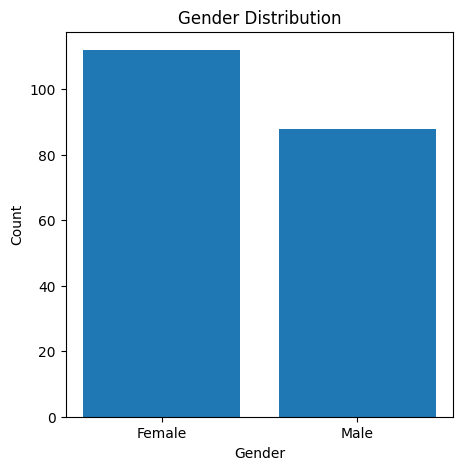

In [ ]:
# Gender Distribution

gender = df["Gender"].value_counts()

plt.figure(figsize=(5,5))
plt.bar(gender.index, gender.values)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

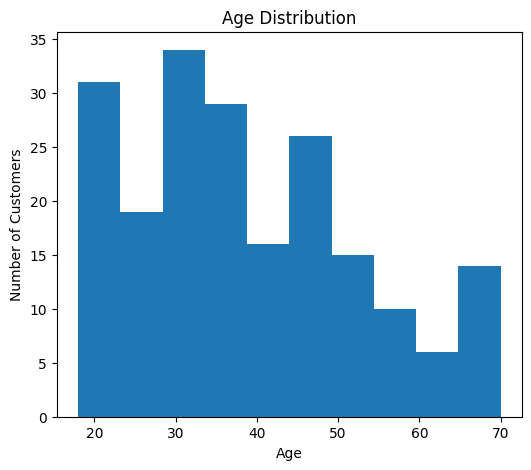

In [ ]:
# Age Distribution

plt.figure(figsize=(6,5))

plt.hist(df["Age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

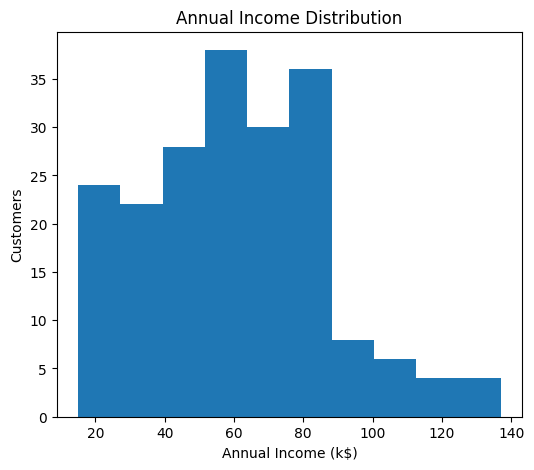

In [ ]:
# Annual income

plt.figure(figsize=(6,5))

plt.hist(df["Annual Income (k$)"], bins=10)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Customers")

plt.show()

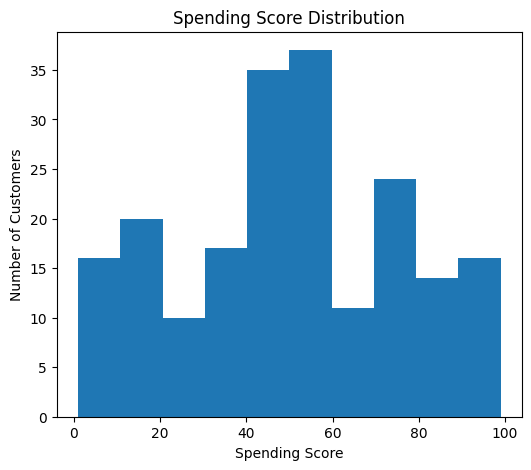

In [ ]:
# Spending score Distribution

plt.figure(figsize=(6,5))
plt.hist(df["Spending Score (1-100)"], bins=10,)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# Correlation matrix

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
corr

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


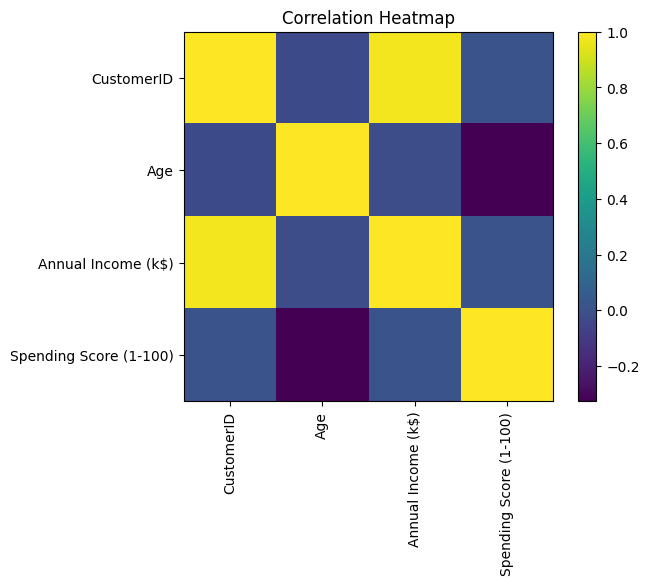

In [ ]:
#Correlation heatmap

plt.imshow(corr, cmap="viridis")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Selecting features

X = df.iloc[:, [3,4]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


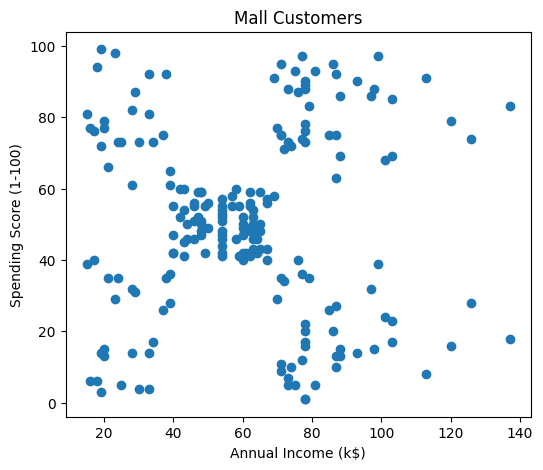

In [ ]:
# Scatter Plot

plt.figure(figsize=(6,5))

plt.scatter(X.iloc[:,0], X.iloc[:,1])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.title("Mall Customers")

plt.show()

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
# Within Cluster Sum of Square

wcss = []

for i in range(1,11):

    model = KMeans(n_clusters=i, random_state=42)

    model.fit(X)

    wcss.append(model.inertia_)

In [46]:
wcss

[269981.28000000014,
 183653.3289473683,
 106348.37306211119,
 73880.64496247198,
 44448.45544793369,
 40825.16946386947,
 33642.57922077922,
 26686.837785187785,
 24766.471609793436,
 23103.122085983905]

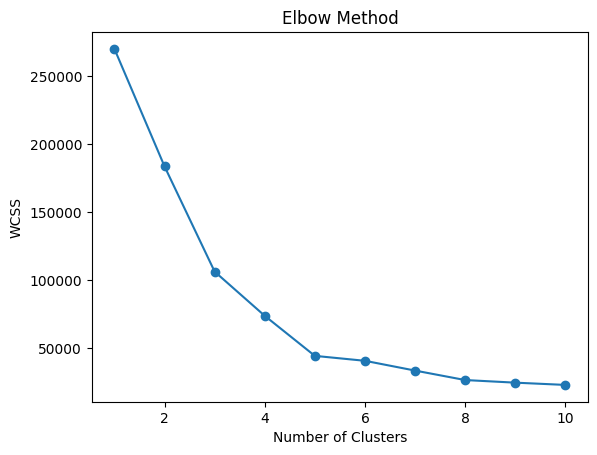

In [48]:
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [50]:
# Train K-Means Model
kmeans = KMeans(n_clusters=5, random_state=42)
y_pred = kmeans.fit_predict(X)

In [52]:
# Cluster Labels
y_pred

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [54]:
# Cluster Centers
kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [57]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_pred)
print("Silhouette Score :", score)

Silhouette Score : 0.553931997444648


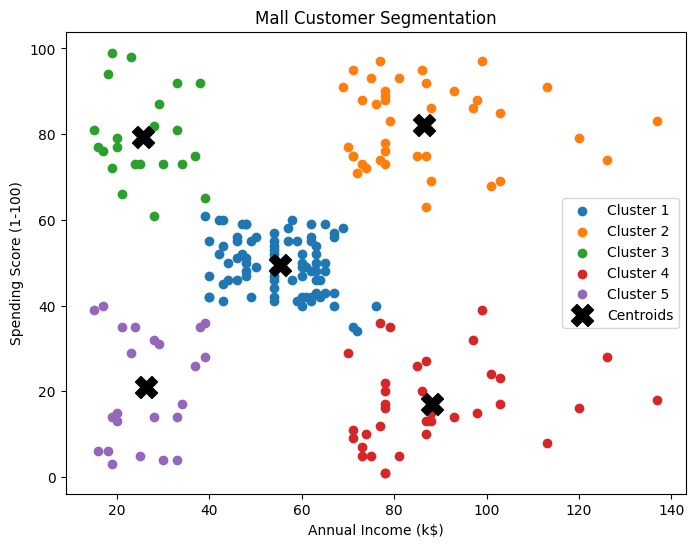

In [58]:
#Visualize customer clusters

plt.figure(figsize=(8,6))

plt.scatter(X.iloc[y_pred==0,0], X.iloc[y_pred==0,1], label="Cluster 1")
plt.scatter(X.iloc[y_pred==1,0], X.iloc[y_pred==1,1], label="Cluster 2")
plt.scatter(X.iloc[y_pred==2,0], X.iloc[y_pred==2,1], label="Cluster 3")
plt.scatter(X.iloc[y_pred==3,0], X.iloc[y_pred==3,1], label="Cluster 4")
plt.scatter(X.iloc[y_pred==4,0], X.iloc[y_pred==4,1], label="Cluster 5")
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=250,
            marker='X',
            c='black',
            label='Centroids')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customer Segmentation")
plt.legend()
plt.show()

In [60]:
# Adding cluster column

df["Cluster"] = y_pred
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [64]:
# Customers in Each Cluster

df["Cluster"].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [63]:
# Predict Cluster for new customer

income = 70
score = 80

new_customer = [[income, score]]

cluster = kmeans.predict(new_customer)

print("Predicted Cluster :", cluster[0])

Predicted Cluster : 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
